# Dynamics and Predictive Power of the Variance Risk Premium in S&P 500 Options
## Part 2 — Econometric Models

**Research question**: Does the implied volatility surface contain predictive information 
for future realized volatility beyond what past returns alone provide?

| Section | Content | Key question |
|---------|---------|-------------|
| 1 | Setup | — |
| 2 | Historical benchmarks | What does the return history predict? |
| 3 | Implied volatility models | What do option prices reveal? |
| 4 | Surface structure (Panel) | Is the surface's information reducible to ATM IV? |
| 5 | Surface factor models (PCA) | How to exploit the full surface efficiently? |
| 6 | Hybrid models | Does IV add to historical information? |
| 7 | Forecast evaluation | Which model wins out-of-sample? |
| 8 | Trading application | Does statistical accuracy translate to economic value? |


## 1 · Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
import warnings, os, glob
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_white
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from scipy import stats
import yfinance as yf 
import pickle

from utilities.ts_construction import extract_daily_metrics
from utilities.linear_regression import ols, reg_table
from utilities.fixed_random_effects import within_estimator, build_surface_panel


In [2]:
# ── Pour recharger dans un autre notebook ─────────────────────────────────────
with open('time_series.pkl', 'rb') as f:
    ts = pickle.load(f)
reg_overlap    = ts['reg_overlap']
reg_nonoverlap = ts['reg_nonoverlap']
metrics        = ts['metrics']
df             = ts['df']
spot_ts         = ts['spot_ts']
log_ret       = ts['log_ret']

In [3]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})

# ── User settings ──────────────────────────────────────────────────────────────
DATA_FOLDER   = './data'        # folder containing all YYYY-MM-DD.csv files
TARGET_TENOR  = 30              # target tenor in days for daily metrics
WING_LOW      = -0.15           # put-wing lower bound (log-moneyness)
WING_HIGH_PUT = -0.05           # put-wing upper bound
WING_LOW_CALL =  0.05           # call-wing lower bound
WING_HIGH     =  0.15           # call-wing upper bound
RV_WINDOW     = 21              # rolling window for realized vol (trading days)

print("Libraries loaded")

Libraries loaded


In [4]:
# ── Import VIX ─────────────────────────────────────────────────────────────────
vix = yf.Ticker("^VIX")
hist = vix.history(start="2017-06-09", end="2018-06-08")
Vix_close = hist["Close"]
Vix_close.index = Vix_close.index.tz_localize(None)

# ── Overlapping ────────────────────────────────────────────────────────────────
reg = reg_overlap.copy()
reg = reg.join(Vix_close.rename("vix"), how="left")
reg['vix_norm']       = reg['vix'] / 100
reg['vix_atm_spread'] = reg['vix_norm'] - reg['atm_iv']

# ── Non-overlapping ────────────────────────────────────────────────────────────
reg_no = reg_nonoverlap.copy()
reg_no = reg_no.join(Vix_close.rename("vix"), how="left")
reg_no['vix_norm']       = reg_no['vix'] / 100
reg_no['vix_atm_spread'] = reg_no['vix_norm'] - reg_no['atm_iv']

print(f"Overlapping    : N = {len(reg.dropna(subset=['vix']))}")
print(f"Non-overlapping: N = {len(reg_no.dropna(subset=['vix']))}")


Overlapping    : N = 211
Non-overlapping: N = 11


## 2 · Historical Benchmarks

These models use **only past return information** — no option data. 
They answer the question: *what can the return history alone predict about future volatility?* 
Any option-implied model must beat these benchmarks to justify its complexity.

| Model | Information set | Role |
|-------|----------------|------|
| Historical Mean | none | naïve floor |
| AR(1) | $RV_{t-1}$ | short-memory baseline |
| HAR | $RV^d_t, RV^w_t, RV^m_t$ | multi-horizon benchmark |
| EGARCH(1,1) | $r_t$ | conditional variance dynamics |

### 2.1 Historical Mean

The naïve forecast $\widehat{RV}_{t+21} = \bar{RV}$. 
Any model failing to beat this is uninformative.

In [5]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

y_full    = reg_overlap['rv_forward'].dropna()
hist_mean = y_full.mean()
print(f'Historical Mean : {hist_mean:.4f}')
print(f'RMSE : {np.sqrt(np.mean((y_full - hist_mean)**2)):.4f}')
print(f'MAE  : {np.mean(np.abs(y_full - hist_mean)):.4f}')

Historical Mean : 0.1166
RMSE : 0.0804
MAE  : 0.0660


### 2.2 HAR (Corsi, 2009)

$$\text{Var}^{\text{fwd}}_t = \beta_0 + \beta_d RV^d_t + \beta_w RV^w_t + \beta_m RV^m_t + \varepsilon_t$$

We work in **variance** space following Andersen et al. (2003). 
Daily variance proxy: $r_t^2 \times 252$. This is noisy relative to true intraday-based RV — 
a limitation of the dataset that will reduce the power of the multi-horizon components.

HAR DATASET
Observations : 211
Period       : 2017-07-10 → 2018-05-09

Descriptive statistics
           rv_d      rv_w      rv_m  target_var
count  211.0000  211.0000  211.0000    211.0000
mean     0.0193    0.0193    0.0190      0.0201
std      0.0686    0.0428    0.0257      0.0265
min      0.0000    0.0001    0.0011      0.0009
25%      0.0002    0.0021    0.0031      0.0037
50%      0.0019    0.0066    0.0052      0.0081
75%      0.0130    0.0157    0.0245      0.0240
max      0.8642    0.3018    0.0938      0.0974


HAR-RV RESULTS
         coef  std err  t-stat  p-value
const  0.0155   0.0088  1.7702   0.0767
rv_d   0.0417   0.0077  5.4206   0.0000
rv_w  -0.0004   0.0326 -0.0110   0.9912
rv_m   0.1966   0.1541  1.2760   0.2020

Model fit
----------------------------------------
R²       : 0.0600
Adj R²   : 0.0464
AIC      : -938.95
BIC      : -925.54
N obs    : 211


HAR vs AR(1)
F-statistic : 1.09
p-value     : 0.3369


LJUNG-BOX TEST
      lb_stat  lb_pvalue
5    807.3987      

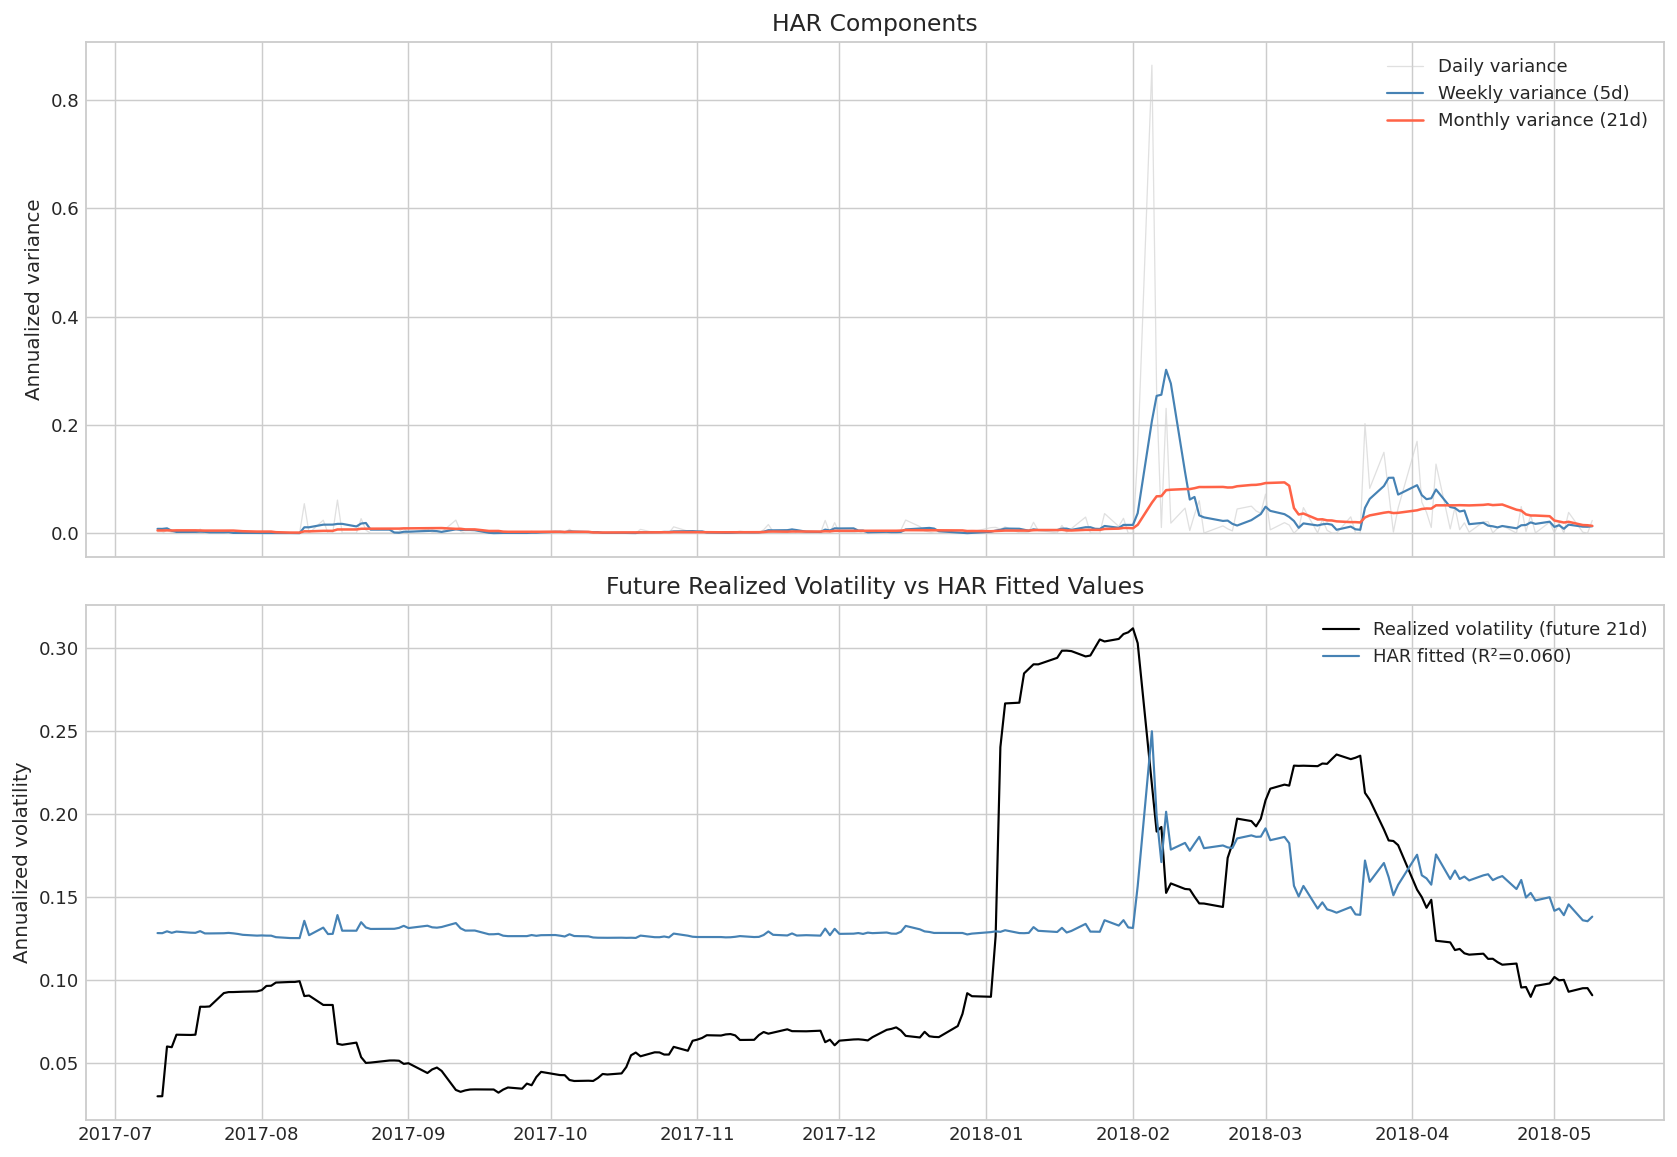

In [6]:
# =============================================================================
# HAR-RV Benchmark (Corsi, 2009)
# Target : future realized variance over next 21 trading days
# =============================================================================

from statsmodels.stats.diagnostic import acorr_ljungbox

# -----------------------------------------------------------------------------
# 1. Daily realized variance proxy
# -----------------------------------------------------------------------------

rv_daily_var = (log_ret ** 2) * 252

df_har = pd.DataFrame(index=log_ret.index)

# HAR components
df_har['rv_d'] = rv_daily_var
df_har['rv_w'] = rv_daily_var.rolling(5).mean()
df_har['rv_m'] = rv_daily_var.rolling(21).mean()

# -----------------------------------------------------------------------------
# 2. Target variable
# -----------------------------------------------------------------------------

df_har = df_har.join(
    reg_overlap[['rv_forward']],
    how='inner'
)

# Future realized variance
df_har['target_var'] = df_har['rv_forward'] ** 2

df_har = df_har.dropna()

print("=" * 70)
print("HAR DATASET")
print("=" * 70)
print(f"Observations : {len(df_har)}")
print(f"Period       : {df_har.index[0].date()} → {df_har.index[-1].date()}")

print("\nDescriptive statistics")
print(
    df_har[
        ['rv_d', 'rv_w', 'rv_m', 'target_var']
    ].describe().round(4)
)

# -----------------------------------------------------------------------------
# 3. Estimate HAR
# -----------------------------------------------------------------------------

y = df_har['target_var']

X = sm.add_constant(
    df_har[['rv_d', 'rv_w', 'rv_m']]
)

har_model = sm.OLS(
    y,
    X
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 21}
)

# -----------------------------------------------------------------------------
# 4. Results
# -----------------------------------------------------------------------------

print("\n")
print("=" * 70)
print("HAR-RV RESULTS")
print("=" * 70)

coef_table = pd.DataFrame({
    'coef'    : har_model.params,
    'std err' : har_model.bse,
    't-stat'  : har_model.tvalues,
    'p-value' : har_model.pvalues
}).round(4)

print(coef_table)

print("\nModel fit")
print("-" * 40)
print(f"R²       : {har_model.rsquared:.4f}")
print(f"Adj R²   : {har_model.rsquared_adj:.4f}")
print(f"AIC      : {har_model.aic:.2f}")
print(f"BIC      : {har_model.bic:.2f}")
print(f"N obs    : {int(har_model.nobs)}")

# -----------------------------------------------------------------------------
# 5. HAR structure test
# -----------------------------------------------------------------------------

f_har = har_model.f_test(
    '(rv_w = 0), (rv_m = 0)'
)

print("\n")
print("=" * 70)
print("HAR vs AR(1)")
print("=" * 70)

print(
    f"F-statistic : {float(f_har.fvalue):.2f}\n"
    f"p-value     : {float(f_har.pvalue):.4f}"
)

# -----------------------------------------------------------------------------
# 6. Residual autocorrelation
# -----------------------------------------------------------------------------

lb = acorr_ljungbox(
    har_model.resid,
    lags=[5, 10, 21],
    return_df=True
)

print("\n")
print("=" * 70)
print("LJUNG-BOX TEST")
print("=" * 70)

print(
    lb[['lb_stat', 'lb_pvalue']]
    .round(4)
    .to_string()
)

# -----------------------------------------------------------------------------
# 7. Store fitted values
# -----------------------------------------------------------------------------

df_har['har_fitted_var'] = har_model.fittedvalues
df_har['har_resid']      = har_model.resid

# Conversion en volatilité annualisée
df_har['har_fitted_vol'] = np.sqrt(
    np.maximum(df_har['har_fitted_var'], 0)
)

# -----------------------------------------------------------------------------
# 8. Visualization
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(13, 9),
    sharex=True
)

# --------------------------------------------------
# Panel A : HAR components
# --------------------------------------------------

ax = axes[0]

ax.plot(
    df_har.index,
    df_har['rv_d'],
    color='lightgray',
    lw=0.7,
    alpha=0.7,
    label='Daily variance'
)

ax.plot(
    df_har.index,
    df_har['rv_w'],
    color='steelblue',
    lw=1.2,
    label='Weekly variance (5d)'
)

ax.plot(
    df_har.index,
    df_har['rv_m'],
    color='tomato',
    lw=1.4,
    label='Monthly variance (21d)'
)

ax.set_title('HAR Components')
ax.set_ylabel('Annualized variance')
ax.legend()

# --------------------------------------------------
# Panel B : Forecasted vs realized volatility
# --------------------------------------------------

ax = axes[1]

ax.plot(
    df_har.index,
    df_har['rv_forward'],
    color='black',
    lw=1.2,
    label='Realized volatility (future 21d)'
)

ax.plot(
    df_har.index,
    df_har['har_fitted_vol'],
    color='steelblue',
    lw=1.2,
    label=f'HAR fitted (R²={har_model.rsquared:.3f})'
)

ax.set_title(
    'Future Realized Volatility vs HAR Fitted Values'
)

ax.set_ylabel('Annualized volatility')
ax.legend()

plt.tight_layout()
plt.show()

### 2.3 EGARCH(1,1)

$$\log \sigma^2_t = \omega + \alpha \left(\frac{|\varepsilon_{t-1}|}{\sigma_{t-1}} - \sqrt{\frac{2}{\pi}}\right) + \gamma \frac{\varepsilon_{t-1}}{\sigma_{t-1}} + \beta \log \sigma^2_{t-1}$$

The leverage term $\gamma < 0$ captures the asymmetric response to negative shocks. 
ARCH effects detected in HAR residuals (LM test, see above) justify this model.

In [7]:
from arch import arch_model

# Fit EGARCH(1,1) on log-returns
ret_series = log_ret.dropna() * 100   # arch_model expects % returns for numerical stability
egarch = arch_model(ret_series, vol='EGARCH', p=1, q=1, dist='Normal')
res_egarch = egarch.fit(disp='off')
print(res_egarch.summary())

# Annualised conditional volatility forecast
egarch_vol = np.sqrt(res_egarch.conditional_volatility ** 2 * 252) / 100
egarch_vol.name = 'egarch_vol'
print(f'\nLeverage effect γ = {res_egarch.params["alpha[1]"]:.4f}  ',
      f'(p = {res_egarch.pvalues["alpha[1]"]:.4f})')

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                   spot   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -239.907
Distribution:                  Normal   AIC:                           487.814
Method:            Maximum Likelihood   BIC:                           501.931
                                        No. Observations:                  252
Date:                Wed, Jun 10 2026   Df Residuals:                      251
Time:                        21:09:40   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1521  3.270e-02      4.651  3.296e-06 [8.802e-0

## 3 · Implied Volatility Models

These models use **only option-implied information** — no return history. 
The question is: *what do option prices reveal about future realized volatility?*

All regressions use Newey-West (HAC) standard errors with 20 lags to correct for the 
overlapping-window autocorrelation induced by the 21-day forward RV construction.

### 3.1 Nested OLS Models

We estimate four nested models to assess the marginal contribution of each surface feature:

| Model | Regressors |
|-------|------------|
| M1 | ATM IV |
| M2 | ATM IV + Skew |
| M3 | ATM IV + Skew + Convexity |
| M4 | ATM IV + Skew + Convexity + VIX–ATM spread |

In [8]:
y = reg_overlap['rv_forward']

In [9]:
print("═"*62)
print("MODEL 1 — Baseline: RV_fwd ~ ATM_IV")
print("═"*62)
r1 = ols(y, reg[['atm_iv']])
reg_table(r1, ['Const', 'ATM_IV'])

══════════════════════════════════════════════════════════════
MODEL 1 — Baseline: RV_fwd ~ ATM_IV
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0112    0.0171    0.658    0.5114 
ATM_IV                    0.8192    0.1266    6.471    0.0000 ***
──────────────────────────────────────────────────────────────
R²                        0.1669
Adj. R²                   0.1629
N                            211
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [10]:
print("\n" + "═"*62)
print("MODEL 2 — RV_fwd ~ ATM_IV + Skew")
print("═"*62)
r2 = ols(y, reg[['atm_iv', 'skew']])
reg_table(r2, ['Const', 'ATM_IV', 'Skew'])


══════════════════════════════════════════════════════════════
MODEL 2 — RV_fwd ~ ATM_IV + Skew
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0603    0.0213    2.838    0.0051 **
ATM_IV                    0.9124    0.1544    5.909    0.0000 ***
Skew                     -0.6913    0.2221   -3.112    0.0022 **
──────────────────────────────────────────────────────────────
R²                        0.1798
Adj. R²                   0.1695
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [11]:
print("\n" + "═"*62)
print("MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity")
print("═"*62)
r3 = ols(y, reg[['atm_iv', 'skew', 'convexity']])
reg_table(r3, ['Const', 'ATM_IV', 'Skew', 'Convexity'])


══════════════════════════════════════════════════════════════
MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0183    0.0300    0.611    0.5424 
ATM_IV                    1.1146    0.1845    6.043    0.0000 ***
Skew                     -0.7201    0.2207   -3.263    0.0013 **
Convexity                 0.6475    0.3296    1.965    0.0512 
──────────────────────────────────────────────────────────────
R²                        0.1992
Adj. R²                   0.1841
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [12]:
reg['vix_atm_spread'] = reg['vix_norm'] - reg['atm_iv']

# Reconstruire y proprement sur le bon index
y = reg['rv_forward'].dropna()
common_idx = y.index.intersection(
    reg[['atm_iv', 'skew', 'convexity', 'vix_atm_spread']].dropna().index
)
y_clean = y.loc[common_idx]
X_clean = reg.loc[common_idx, ['atm_iv', 'skew', 'convexity', 'vix_atm_spread']]

r6 = ols(y_clean, X_clean)
reg_table(r6, ['Const', 'ATM_IV', 'Skew', 'Convexity', 'VIX_ATM_Spread'])


──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.1150    0.0443    2.593    0.0104 *
ATM_IV                    0.6688    0.2367    2.826    0.0053 **
Skew                     -0.7545    0.2160   -3.493    0.0006 ***
Convexity                -0.9389    0.6337   -1.482    0.1404 
VIX_ATM_Spread            1.0241    0.3523    2.907    0.0042 **
──────────────────────────────────────────────────────────────
R²                        0.2399
Adj. R²                   0.2206
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [13]:
data  = reg[['atm_iv', 'skew', 'convexity' , 'vix_atm_spread' ,'rv_forward']].dropna()
X_m6  = sm.add_constant(data[['atm_iv', 'skew', 'convexity' , 'vix_atm_spread']].values)
y_m6  = data['rv_forward'].values

res_nw  = sm.OLS(y_m6, X_m6).fit(cov_type='HAC', cov_kwds={'maxlags': 20})

print(res_nw.summary())

jb_stat,    jb_p          = stats.jarque_bera(res_nw.resid)
dw                         = durbin_watson(res_nw.resid)
bg_stat,    bg_p,   _, _  = acorr_breusch_godfrey(res_nw, nlags=21)
white_stat, white_p, _, _ = het_white(res_nw.resid, X_m6)

print(f"Jarque-Bera     : stat={jb_stat:.3f}  p={jb_p:.4f}  "
      f"{'reject normality'          if jb_p    < 0.05 else 'cannot reject normality'}")
print(f"Durbin-Watson   : {dw:.4f}            "
      f"{'autocorrelation present'   if abs(dw-2)>0.5  else 'no strong autocorrelation'}")
print(f"White           : stat={white_stat:.3f}  p={white_p:.4f}  "
      f"{'reject homoscedasticity'   if white_p < 0.05 else 'cannot reject homoscedasticity'}")
print(f"Breusch-Godfrey : stat={bg_stat:.3f}  p=  {bg_p:.4f}  "
      f"{'reject no autocorrelation' if bg_p    < 0.05 else 'cannot reject no autocorrelation'}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     3.936
Date:                Wed, 10 Jun 2026   Prob (F-statistic):            0.00449
Time:                        21:09:40   Log-Likelihood:                 201.76
No. Observations:                 163   AIC:                            -393.5
Df Residuals:                     158   BIC:                            -378.1
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1150      0.065      1.767      0.0

### 3.2 Mincer-Zarnowitz Test

Is ATM IV an unbiased predictor of future RV?

$$RV^{\text{fwd}}_t = \alpha + \beta \cdot IV_t + u_t$$

- $H_0: \alpha = 0$ — no systematic bias
- $H_0: \beta = 1$ — IV is a proportional predictor

Rejection of $\beta = 1$ (with $\beta < 1$) is the econometric signature of a positive VRP: 
the market systematically overprices volatility.

In [14]:
# Mincer-Zarnowitz on the ATM IV model (M1)
y_mz = reg_overlap['rv_forward'].dropna()
X_mz = sm.add_constant(reg_overlap['atm_iv'].reindex(y_mz.index).dropna())
y_mz = y_mz.reindex(X_mz.index)

res_mz = sm.OLS(y_mz, X_mz).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
alpha, beta = res_mz.params
se_alpha, se_beta = res_mz.bse

t_alpha = alpha / se_alpha
t_beta  = (beta - 1) / se_beta
p_alpha = 2 * (1 - stats.t.cdf(abs(t_alpha), df=res_mz.df_resid))
p_beta  = 2 * (1 - stats.t.cdf(abs(t_beta),  df=res_mz.df_resid))

print('═'*55)
print('Mincer-Zarnowitz : IV as unbiased predictor of RV')
print('═'*55)
print(f'α = {alpha:.4f}   t = {t_alpha:.2f}   p = {p_alpha:.4f}  ',
      f'  {"reject H0: α=0" if p_alpha < 0.05 else "cannot reject α=0"}')
print(f'β = {beta:.4f}   t = {t_beta:.2f}   p = {p_beta:.4f}  ',
      f'  {"reject H0: β=1" if p_beta  < 0.05 else "cannot reject β=1"}')
print(f'\nInterpretation: IV {"over-estimates" if alpha > 0 and beta < 1 else "is an unbiased predictor of"} future RV → VRP is {"positive" if alpha > 0 else "zero"} on average')

═══════════════════════════════════════════════════════
Mincer-Zarnowitz : IV as unbiased predictor of RV
═══════════════════════════════════════════════════════
α = 0.0112   t = 0.30   p = 0.7680     cannot reject α=0
β = 0.8192   t = -0.84   p = 0.3991     cannot reject β=1

Interpretation: IV over-estimates future RV → VRP is positive on average


## 4 · Surface Structure — Panel Models

The IV surface is a panel: $N$ expiries observed at each date $t$. 
Before exploiting the full surface via PCA, we characterise its internal structure. 
The central question here is: **can ATM IV alone summarise the surface, 
or is there systematic heterogeneity across maturities that it misses?**

If expiry fixed effects are significant (F-test below), the surface cannot be reduced to a scalar — 
this motivates the factor approach of Section 5.

> **Note**: this section does not forecast RV. It characterises the surface. 
The forecasting application of this structure comes in Section 5 (PCA).

### 4.1 Pooled OLS → Fixed Effects → Random Effects

$$IV_{it} = \beta_1 \cdot \text{ATM\_IV}_{it} + \beta_2 \cdot \text{VIX-spread}_{it} + (\alpha_i) + \varepsilon_{it}$$

**Sequence**:
1. Pooled OLS — ignores expiry structure
2. Fixed Effects — absorbs expiry-level intercepts via within-demeaning
3. Random Effects — assumes $\alpha_i \sim \mathcal{N}(0, \sigma^2_\alpha)$
4. Hausman test — $H_0: \alpha_i \perp X_{it}$ (RE consistent)

In [15]:
from linearmodels.panel import PanelOLS, RandomEffects

panel_surf = build_surface_panel(df, reg_overlap,
                                  wing_lo=WING_LOW, wing_hi_p=WING_HIGH_PUT,
                                  wing_lo_c=WING_LOW_CALL, wing_hi=WING_HIGH)

vix_norm = reg['vix'] / 100
panel_surf['vix_norm']      = panel_surf['date'].map(vix_norm)
panel_surf['vix_atm_spread'] = panel_surf['vix_norm'] - panel_surf['atm_iv']
panel_surf = panel_surf.dropna(subset=['vix_atm_spread'])

x_cols = ['atm_iv', 'vix_atm_spread']
print(f'Panel: {len(panel_surf)} obs  |  {panel_surf["expiry"].nunique()} expiries  |  {panel_surf["date"].nunique()} dates')

# Pooled OLS
r_pooled = ols(panel_surf['rv_forward'].values, panel_surf[x_cols].values)
print('\nPooled OLS:')
print(f'  R² = {r_pooled["r2"]:.4f}')

Panel: 2240 obs  |  21 expiries  |  211 dates

Pooled OLS:
  R² = 0.1567


In [16]:
# F-test for entity fixed effects
fe_surf = within_estimator(panel_surf, 'rv_forward', x_cols, 'expiry')
N, NT, K = panel_surf['expiry'].nunique(), len(panel_surf), len(x_cols)
F_stat = ((np.sum(r_pooled['resid']**2) - np.sum(fe_surf.resid**2)) / (N-1)) / \
          (np.sum(fe_surf.resid**2) / (NT - N - K))
F_p = 1 - stats.f.cdf(F_stat, N-1, NT-N-K)
print(f'F-test entity effects : F = {F_stat:.3f},  p = {F_p:.4f}  → {"Significant ✓" if F_p < 0.05 else "Not significant"}')

# FE and RE estimation
panel_idx = panel_surf.set_index(['expiry', 'date'])
y_pan = panel_idx['rv_forward']
X_pan = sm.add_constant(panel_idx[x_cols])

fe_lm = PanelOLS(y_pan, X_pan[x_cols], entity_effects=True).fit()
print('\n' + '═'*62)
print('FIXED EFFECTS')
print(fe_lm.summary.tables[1])

F-test entity effects : F = 17.040,  p = 0.0000  → Significant ✓

══════════════════════════════════════════════════════════════
FIXED EFFECTS
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
atm_iv             0.0026     0.0867     0.0295     0.9765     -0.1674      0.1726
vix_atm_spread     0.6518     0.0517     12.600     0.0000      0.5504      0.7533


In [17]:
re_lm = RandomEffects(y_pan, X_pan).fit()
print('RANDOM EFFECTS')
print(re_lm.summary.tables[1])

# Hausman test
b_fe = fe_lm.params.values
b_re = re_lm.params[x_cols].values
V_fe = fe_lm.cov.values
V_re = re_lm.cov.loc[x_cols, x_cols].values
diff = b_fe - b_re
H    = float(diff @ np.linalg.inv(V_fe - V_re) @ diff)
p    = 1 - stats.chi2.cdf(H, df=len(b_fe))
print(f'\nHausman : stat = {H:.4f}  p = {p:.4f}')
print(f'→ {"Reject RE — use FE" if p < 0.05 else "Cannot reject RE — prefer RE"}')

RANDOM EFFECTS
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
const              0.0965     0.0124     7.7706     0.0000      0.0722      0.1209
atm_iv             0.1506     0.0832     1.8099     0.0705     -0.0126      0.3138
vix_atm_spread     0.6226     0.0514     12.120     0.0000      0.5219      0.7233

Hausman : stat = 12.9536  p = 0.0015
→ Reject RE — use FE


## 5 · Surface Factor Models — PCA

The panel analysis showed that the surface contains systematic heterogeneity beyond ATM IV. 
We now extract this information efficiently via PCA (Cont & da Fonseca, 2002).

**Motivation**: rather than hand-crafting summary statistics (ATM IV, skew, convexity) 
that capture only part of the surface variation, PCA extracts the latent factors that 
explain the maximum variance:

- **PC1** — level: parallel shift of the surface
- **PC2** — slope: tilt across maturities
- **PC3** — curvature: smile effect

We then regress $RV^{\text{fwd}}$ on these factors.

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Build strike×maturity IV panel — one row per date
# Pivot: rows = dates, columns = (moneyness_bin, maturity_bin)
panel_pca = build_surface_panel(df, reg_overlap,
                                 wing_lo=WING_LOW, wing_hi_p=WING_HIGH_PUT,
                                 wing_lo_c=WING_LOW_CALL, wing_hi=WING_HIGH)

# Pivot to wide format: each (expiry) becomes a column
iv_wide = panel_pca.pivot_table(index='date', columns='expiry', values='atm_iv')
iv_wide = iv_wide.fillna(iv_wide.mean())

print(f'Surface panel: {iv_wide.shape[0]} dates × {iv_wide.shape[1]} expiry columns')

# Standardise and fit PCA
scaler = StandardScaler()
iv_scaled = scaler.fit_transform(iv_wide)

pca = PCA(n_components=5)
factors = pca.fit_transform(iv_scaled)

print('\nExplained variance ratio:')
for i, r in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {r:.3f}  (cumulative: {pca.explained_variance_ratio_[:i+1].sum():.3f})')

df_pca = pd.DataFrame(factors[:, :3], index=iv_wide.index,
                       columns=['PC1_level', 'PC2_skew', 'PC3_curv'])
df_pca = df_pca.join(reg_overlap['rv_forward'], how='inner').dropna()

Surface panel: 211 dates × 21 expiry columns

Explained variance ratio:
  PC1: 0.427  (cumulative: 0.427)
  PC2: 0.112  (cumulative: 0.539)
  PC3: 0.080  (cumulative: 0.618)
  PC4: 0.056  (cumulative: 0.675)
  PC5: 0.048  (cumulative: 0.722)


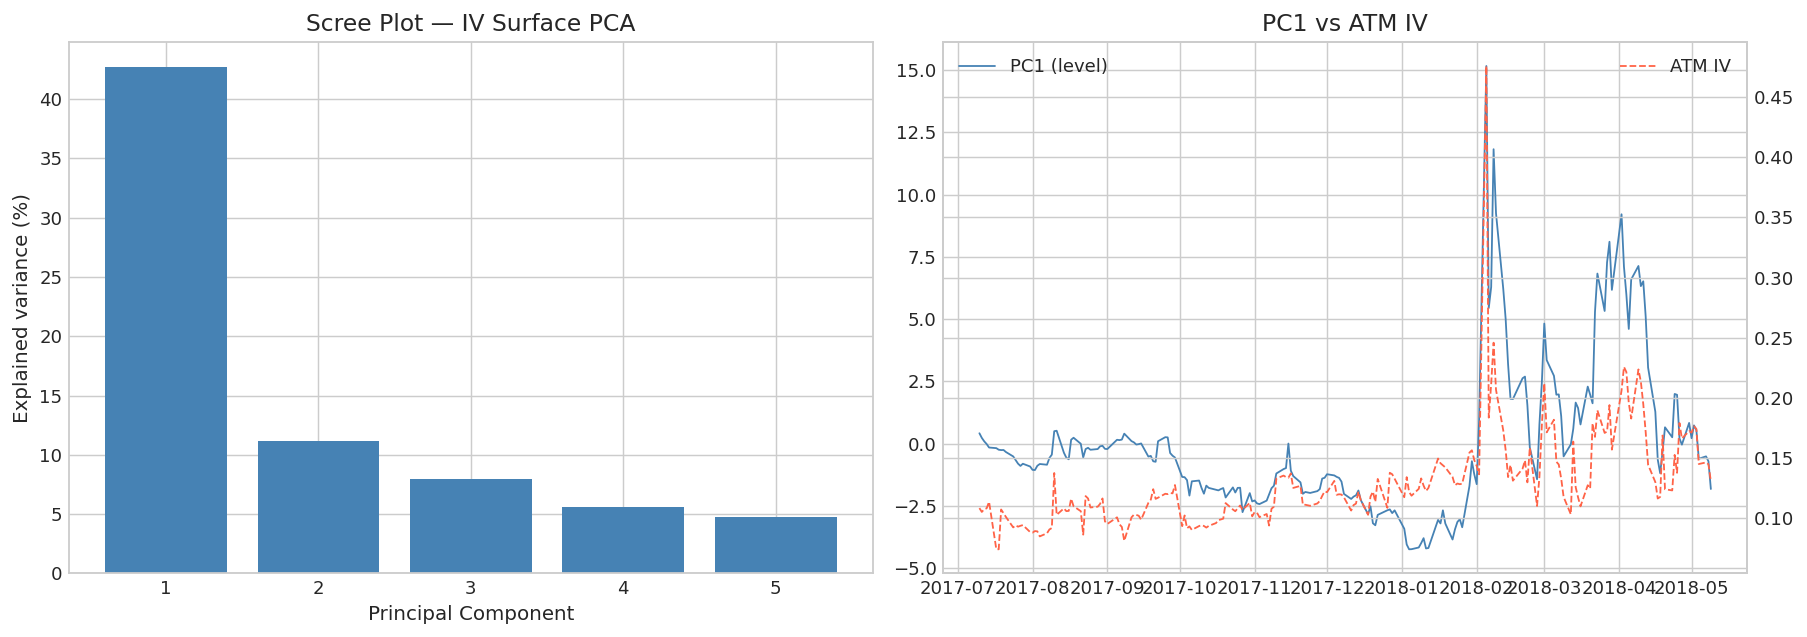

                            OLS Regression Results                            
Dep. Variable:             rv_forward   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     4.720
Date:                Wed, 10 Jun 2026   Prob (F-statistic):            0.00330
Time:                        21:09:44   Log-Likelihood:                 248.11
No. Observations:                 211   AIC:                            -488.2
Df Residuals:                     207   BIC:                            -474.8
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1166      0.020      5.896      0.0

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 6), pca.explained_variance_ratio_ * 100, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title('Scree Plot — IV Surface PCA')

# PC1 vs ATM IV
axes[1].plot(df_pca.index, df_pca['PC1_level'], color='steelblue', lw=1, label='PC1 (level)')
ax2 = axes[1].twinx()
ax2.plot(reg_overlap['atm_iv'].reindex(df_pca.index), color='tomato', lw=1, ls='--', label='ATM IV')
axes[1].set_title('PC1 vs ATM IV')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Regression: PCA factors → RV forward
X_pca = sm.add_constant(df_pca[['PC1_level', 'PC2_skew', 'PC3_curv']])
y_pca = df_pca['rv_forward']
m_pca = sm.OLS(y_pca, X_pca).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
print(m_pca.summary())

## 6 · Hybrid Models

We now combine historical and option-implied information. 
The central question: **does IV add predictive content beyond what past volatility already captures?**

| Model | Information set |
|-------|----------------|
| HAR-IV | HAR components + ATM IV (variance) |
| HAR-PCA | HAR components + PC1, PC2, PC3 |

The encompassing regression below tests this directly.

### 6.1 HAR-IV

$$\text{Var}^{\text{fwd}}_t = \beta_0 + \beta_d RV^d_t + \beta_w RV^w_t + \beta_m RV^m_t + \gamma IV^2_t + \varepsilon_t$$

If $\gamma$ is significant: IV carries information not spanned by the HAR components.

In [20]:
rv_daily_var = (log_ret ** 2) * 252
df_hybrid = pd.DataFrame({
    'rv_d': rv_daily_var,
    'rv_w': rv_daily_var.rolling(5).mean(),
    'rv_m': rv_daily_var.rolling(21).mean(),
}, index=log_ret.index)
df_hybrid = df_hybrid.join(reg_overlap[['rv_forward', 'atm_iv']], how='inner').dropna()
df_hybrid['var_forward'] = df_hybrid['rv_forward'] ** 2
df_hybrid['iv_var']      = df_hybrid['atm_iv'] ** 2

X_hariv = sm.add_constant(df_hybrid[['rv_d', 'rv_w', 'rv_m', 'iv_var']])
m_hariv = sm.OLS(df_hybrid['var_forward'], X_hariv).fit(cov_type='HAC', cov_kwds={'maxlags': 21})

coef_table = pd.DataFrame({
    'coef'   : m_hariv.params,
    'std err': m_hariv.bse,
    't-stat' : m_hariv.tvalues,
    'p-value': m_hariv.pvalues
}).round(4)
print(coef_table)
print(f'\nR² = {m_hariv.rsquared:.4f}  |  Adj R² = {m_hariv.rsquared_adj:.4f}')

# Marginal contribution of IV beyond HAR (F-test)
f_iv = m_hariv.f_test('iv_var = 0')
print(f'\nMarginal IV (F-test): F = {float(f_iv.fvalue):.2f}  p = {float(f_iv.pvalue):.4f}')
print(f'→ IV adds information beyond HAR: {float(f_iv.pvalue) < 0.05}')

          coef  std err  t-stat  p-value
const   0.0116   0.0078  1.4790   0.1391
rv_d   -0.0234   0.0667 -0.3514   0.7253
rv_w   -0.0122   0.0353 -0.3446   0.7304
rv_m    0.1618   0.1646  0.9831   0.3256
iv_var  0.3372   0.3113  1.0832   0.2787

R² = 0.0706  |  Adj R² = 0.0525

Marginal IV (F-test): F = 1.17  p = 0.2800
→ IV adds information beyond HAR: False


### 6.2 Encompassing Regression

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \widehat{RV}^{\text{HAR}}_t + \beta_2 \widehat{RV}^{\text{IV}}_t + u_t$$

- $\beta_2 > 0$ significant: IV not spanned by HAR
- $\beta_1 > 0$ significant: HAR not spanned by IV
- Both significant: neither model encompasses the other

In [21]:
# Build HAR fitted values on the overlapping sample
rv_daily_var = (log_ret ** 2) * 252
df_enc = pd.DataFrame({
    'rv_d': rv_daily_var,
    'rv_w': rv_daily_var.rolling(5).mean(),
    'rv_m': rv_daily_var.rolling(21).mean(),
}).join(reg_overlap[['rv_forward', 'atm_iv']], how='inner').dropna()

df_enc['var_forward'] = df_enc['rv_forward'] ** 2
df_enc['iv_var']      = df_enc['atm_iv'] ** 2

# HAR fitted values
X_har_enc = sm.add_constant(df_enc[['rv_d', 'rv_w', 'rv_m']])
m_har_enc = sm.OLS(df_enc['var_forward'], X_har_enc).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
df_enc['har_fitted'] = m_har_enc.fittedvalues

# IV fitted values
X_iv_enc = sm.add_constant(df_enc[['iv_var']])
m_iv_enc = sm.OLS(df_enc['var_forward'], X_iv_enc).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
df_enc['iv_fitted'] = m_iv_enc.fittedvalues

# Encompassing regression
X_enc = sm.add_constant(df_enc[['har_fitted', 'iv_fitted']])
m_enc = sm.OLS(df_enc['var_forward'], X_enc).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
print(m_enc.summary())
print()
print('β_HAR =', round(m_enc.params['har_fitted'], 4),
      '  p =', round(m_enc.pvalues['har_fitted'], 4))
print('β_IV  =', round(m_enc.params['iv_fitted'],  4),
      '  p =', round(m_enc.pvalues['iv_fitted'],  4))
print()
print('→ IV adds information beyond HAR:', m_enc.pvalues['iv_fitted'] < 0.05)
print('→ HAR adds information beyond IV:', m_enc.pvalues['har_fitted'] < 0.05)

                            OLS Regression Results                            
Dep. Variable:            var_forward   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     3.603
Date:                Wed, 10 Jun 2026   Prob (F-statistic):             0.0290
Time:                        21:09:44   Log-Likelihood:                 474.00
No. Observations:                 211   AIC:                            -942.0
Df Residuals:                     208   BIC:                            -932.0
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0031      0.015     -0.202      0.8

### 6.3 HAR-PCA

$$\text{Var}^{\text{fwd}}_t = \beta_0 + \beta_d RV^d_t + \beta_w RV^w_t + \beta_m RV^m_t + \gamma_1 PC1_t + \gamma_2 PC2_t + \gamma_3 PC3_t + \varepsilon_t$$

This tests whether the full surface factor structure adds information beyond the HAR components.

In [22]:
df_harpca = df_hybrid.join(df_pca[['PC1_level', 'PC2_skew', 'PC3_curv']], how='inner').dropna()

X_harpca = sm.add_constant(df_harpca[['rv_d', 'rv_w', 'rv_m', 'PC1_level', 'PC2_skew', 'PC3_curv']])
m_harpca = sm.OLS(df_harpca['var_forward'], X_harpca).fit(cov_type='HAC', cov_kwds={'maxlags': 21})

coef_table = pd.DataFrame({
    'coef'   : m_harpca.params,
    'std err': m_harpca.bse,
    't-stat' : m_harpca.tvalues,
    'p-value': m_harpca.pvalues
}).round(4)
print(coef_table)
print(f'\nR² = {m_harpca.rsquared:.4f}  |  Adj R² = {m_harpca.rsquared_adj:.4f}')

# Joint significance of PCA factors beyond HAR
f_pca = m_harpca.f_test('(PC1_level = 0), (PC2_skew = 0), (PC3_curv = 0)')
print(f'\nJoint PCA factors beyond HAR: F = {float(f_pca.fvalue):.2f}  p = {float(f_pca.pvalue):.4f}')
print(f'→ Surface factors add information beyond HAR: {float(f_pca.pvalue) < 0.05}')

             coef  std err  t-stat  p-value
const      0.0101   0.0081  1.2419   0.2143
rv_d       0.0860   0.0354  2.4294   0.0151
rv_w       0.1219   0.1084  1.1247   0.2607
rv_m       0.3156   0.1487  2.1224   0.0338
PC1_level -0.0041   0.0037 -1.1005   0.2711
PC2_skew   0.0024   0.0019  1.2633   0.2065
PC3_curv  -0.0045   0.0025 -1.8058   0.0710

R² = 0.2143  |  Adj R² = 0.1912

Joint PCA factors beyond HAR: F = 1.16  p = 0.3276
→ Surface factors add information beyond HAR: False


## 7 · Forecast Evaluation — Out-of-Sample

In-sample $R^2$ is insufficient: it conflates fit with predictive ability. 
We evaluate all models on their **out-of-sample** performance using an **expanding window** scheme: 
at each date $t$ in the test set, the model is re-estimated on all available history up to $t$.

**Protocol**:
- Train: first 80% of the overlapping sample
- Test: last 20% (~42 observations)
- Expanding window: re-estimate at each test date using all data up to that date

> **Why overlapping for estimation, non-overlapping for evaluation?** 
Overlapping observations maximise the estimation sample. 
However, test-set forecast errors computed from overlapping windows are serially correlated by construction (MA(20) structure), 
which inflates the apparent precision of DM tests. We report this limitation explicitly.

### 7.1 Expanding Window Forecasts

In [23]:
eval_df = reg_overlap.copy()
eval_df = eval_df.join(Vix_close.rename('vix'), how='left')
eval_df['vix_norm']        = eval_df['vix'] / 100
eval_df['vix_atm_spread']  = eval_df['vix_norm'] - eval_df['atm_iv']

rv_d_ = (log_ret ** 2 * 252).reindex(eval_df.index)
eval_df['rv_d'] = rv_d_
eval_df['rv_w'] = rv_d_.rolling(5).mean()
eval_df['rv_m'] = rv_d_.rolling(21).mean()
eval_df = eval_df.dropna(subset=['rv_forward', 'atm_iv', 'rv_past',
                                   'vix_atm_spread', 'rv_d', 'rv_w', 'rv_m'])

n     = len(eval_df)
split = int(n * 0.80)
train = eval_df.iloc[:split]
test  = eval_df.iloc[split:]

# Align PCA factors
eval_pca = eval_df.join(df_pca[['PC1_level', 'PC2_skew', 'PC3_curv']], how='left')

print(f'Train : {len(train)} obs  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test  : {len(test)}  obs  ({test.index[0].date()}  → {test.index[-1].date()})')

# ── Expanding window ──────────────────────────────────────────────────────────
def expanding_forecast(feature_cols, target_col='rv_forward'):
    preds = []
    for i in range(split, n):
        df_train = eval_df.iloc[:i][feature_cols + [target_col]].dropna()
        df_test  = eval_df.iloc[[i]][feature_cols].dropna()
        if len(df_train) < len(feature_cols) + 2 or len(df_test) == 0:
            preds.append(np.nan)
            continue
        m = sm.OLS(df_train[target_col],
                   sm.add_constant(df_train[feature_cols])).fit()
        X_t = sm.add_constant(df_test, has_constant='add')
        preds.append(float(m.predict(X_t).iloc[0]))
    return np.array(preds)

def expanding_forecast_pca(har_cols, pca_cols, target_col='rv_forward'):
    preds = []
    for i in range(split, n):
        all_cols = har_cols + pca_cols
        df_train = eval_pca.iloc[:i][all_cols + [target_col]].dropna()
        df_test  = eval_pca.iloc[[i]][all_cols].dropna()
        if len(df_train) < len(all_cols) + 2 or len(df_test) == 0:
            preds.append(np.nan)
            continue
        m = sm.OLS(df_train[target_col],
                   sm.add_constant(df_train[all_cols])).fit()
        X_t = sm.add_constant(df_test, has_constant='add')
        preds.append(float(m.predict(X_t).iloc[0]))
    return np.array(preds)

y_test = test['rv_forward'].values

forecasts = {}
forecasts['HistMean'] = np.array([eval_df.iloc[:split+i]['rv_forward'].mean()
                                   for i in range(len(test))])
forecasts['HAR']      = expanding_forecast(['rv_d', 'rv_w', 'rv_m'])
forecasts['ATM_IV']   = expanding_forecast(['atm_iv'])
forecasts['IV_full']  = expanding_forecast(['atm_iv', 'skew', 'convexity', 'vix_atm_spread'])
forecasts['PCA']      = expanding_forecast_pca([], ['PC1_level', 'PC2_skew', 'PC3_curv'])
forecasts['HAR_IV']   = expanding_forecast(['rv_d', 'rv_w', 'rv_m', 'atm_iv'])
forecasts['HAR_PCA']  = expanding_forecast_pca(['rv_d', 'rv_w', 'rv_m'],
                                                ['PC1_level', 'PC2_skew', 'PC3_curv'])

print('Expanding window forecasts computed.')
for name, fc in forecasts.items():
    n_valid = np.sum(~np.isnan(fc))
    print(f'  {name:<12}: {n_valid} valid predictions')

Train : 152 obs  (2017-08-07 → 2018-03-14)
Test  : 39  obs  (2018-03-15  → 2018-05-09)
Expanding window forecasts computed.
  HistMean    : 39 valid predictions
  HAR         : 39 valid predictions
  ATM_IV      : 39 valid predictions
  IV_full     : 39 valid predictions
  PCA         : 39 valid predictions
  HAR_IV      : 39 valid predictions
  HAR_PCA     : 39 valid predictions


### 7.2 Error Metrics — RMSE, MAE, QLIKE

| Loss function | Formula | Property |
|--------------|---------|----------|
| RMSE | $\sqrt{\mathbb{E}[(RV - \hat{RV})^2]}$ | symmetric, penalises large errors |
| MAE | $\mathbb{E}[|RV - \hat{RV}|]$ | symmetric, robust to outliers |
| QLIKE | $\mathbb{E}[RV/\hat{RV} - \log(RV/\hat{RV}) - 1]$ | asymmetric, robust loss (Patton, 2011) |

In [24]:
def rmse(y, yhat): return np.sqrt(np.mean((y - yhat)**2))
def mae(y, yhat):  return np.mean(np.abs(y - yhat))
def qlike(y, yhat):
    yhat = np.maximum(yhat, 1e-8)   # avoid log(0)
    return np.mean(y / yhat - np.log(y / yhat) - 1)

print('{:<12}  {:>10}  {:>10}  {:>10}'.format('Model', 'RMSE', 'MAE', 'QLIKE'))
print('─'*46)
metrics_oos = {}
for name, fc in forecasts.items():
    if fc is None: continue
    y_eval = y_test[:len(fc)]
    r, m, q = rmse(y_eval, fc), mae(y_eval, fc), qlike(y_eval, fc)
    metrics_oos[name] = (r, m, q)
    print(f'{name:<12}  {r:>10.4f}  {m:>10.4f}  {q:>10.4f}')

Model               RMSE         MAE       QLIKE
──────────────────────────────────────────────
HistMean          0.0540      0.0390      0.0714
HAR               0.0534      0.0444      0.0659
ATM_IV            0.0593      0.0491      0.0798
IV_full           0.0850      0.0745      0.1242
PCA               0.0683      0.0601      0.1376
HAR_IV            0.0762      0.0651      0.1098
HAR_PCA           0.1012      0.0839  1007370.5323


### 7.3 Diebold-Mariano Tests

$$H_0: \mathbb{E}[d_t] = 0, \quad d_t = L(e_{1t}) - L(e_{2t})$$

DM statistic sign convention: **positive DM → model 2 (challenger) is better than model 1 (benchmark)**.

> **Caveat**: with ~42 test observations and overlapping 21-day forecast errors, 
the DM test has limited power. Results should be interpreted with caution.

In [25]:
from scipy.stats import t as t_dist

def dm_test(y, f1, f2, h=1):
    """Diebold-Mariano test (squared error loss, HAC correction).
    h: forecast horizon (number of steps ahead). For 21-day forecasts, h=21.
    Returns: DM statistic, p-value (two-sided)
    """
    e1 = y - f1
    e2 = y - f2
    d  = e1**2 - e2**2
    T  = len(d)
    d_bar = d.mean()
    # HAC variance (Newey-West with h-1 lags)
    gamma0 = np.var(d, ddof=0)
    gammas = [np.cov(d[j:], d[:-j])[0,1] for j in range(1, h)]
    var_d  = (gamma0 + 2 * sum((1 - j/h) * g for j, g in enumerate(gammas, 1))) / T
    dm_stat = d_bar / np.sqrt(var_d)
    p_val   = 2 * (1 - t_dist.cdf(abs(dm_stat), df=T-1))
    return dm_stat, p_val

# Benchmark: Historical Mean. Test each model against it.
print('Diebold-Mariano tests (squared error, h=21 lags)')
print('H0: model has same accuracy as benchmark')
print('{:<22}  {:>10}  {:>10}  {:>20}'.format('Model vs HistMean', 'DM stat', 'p-value', 'Verdict'))
print('─'*68)
bench = forecasts['HistMean']
for name, fc in forecasts.items():
    if name == 'HistMean' or fc is None: continue
    y_eval = y_test[:len(fc)]
    b_eval = bench[:len(fc)]
    dm, p  = dm_test(y_eval, b_eval, fc, h=21)
    verdict = ('Benchmark better' if dm < 0 else 'Model better') + (' ***' if p < 0.01 else ' **' if p < 0.05 else ' *' if p < 0.1 else '') if p < 0.1 else 'Not significant'
    print(f'{name:<22}  {dm:>10.3f}  {p:>10.4f}  {verdict:>20}')

print()
print('Cross-model DM tests (HAR as reference)')
har_fc = forecasts['HAR']
print('{:<22}  {:>10}  {:>10}  {:>20}'.format('Model vs HAR', 'DM stat', 'p-value', 'Verdict'))
print('─'*68)
for name, fc in forecasts.items():
    if name in ('HistMean', 'HAR') or fc is None: continue
    y_eval  = y_test[:min(len(fc), len(har_fc))]
    fc_eval = fc[:len(y_eval)]
    har_eval= har_fc[:len(y_eval)]
    dm, p   = dm_test(y_eval, har_eval, fc_eval, h=21)
    verdict = ('Benchmark better' if dm < 0 else 'Model better') + (' ***' if p < 0.01 else ' **' if p < 0.05 else ' *' if p < 0.1 else '') if p < 0.1 else 'Not significant'
    print(f'{name:<22}  {dm:>10.3f}  {p:>10.4f}  {verdict:>20}')

Diebold-Mariano tests (squared error, h=21 lags)
H0: model has same accuracy as benchmark
Model vs HistMean          DM stat     p-value               Verdict
────────────────────────────────────────────────────────────────────
HAR                          0.097      0.9229       Not significant
ATM_IV                      -0.660      0.5129       Not significant
IV_full                     -3.883      0.0004  Benchmark better ***
PCA                         -3.868      0.0004  Benchmark better ***
HAR_IV                      -2.675      0.0109   Benchmark better **
HAR_PCA                     -1.987      0.0542    Benchmark better *

Cross-model DM tests (HAR as reference)
Model vs HAR               DM stat     p-value               Verdict
────────────────────────────────────────────────────────────────────
ATM_IV                      -2.804      0.0079  Benchmark better ***
IV_full                     -3.951      0.0003  Benchmark better ***
PCA                         -3.793      0

## 8 · Trading Application — Variance Risk Premium Strategy

Does a statistical forecasting advantage translate into economic value?

**Signal construction** (best OOS model only):

$$\text{Signal}_t = \widehat{RV}_{t,t+21} - IV_t$$

- $\text{Signal}_t > 0$: model predicts RV > IV → options are *cheap* → **Long Vol**
- $\text{Signal}_t < 0$: model predicts RV < IV → options are *expensive* → **Short Vol**

**PnL proxy** (variance swap approximation):

$$\text{PnL}_t = \text{Position}_t \times (RV_{t,t+21} - IV_t)$$

> The strategy is constructed **exclusively from OOS forecasts** to avoid look-ahead bias. 
We also report results excluding February 5, 2018 (Volmageddon) to assess robustness.

In [26]:
# Select best model from Section 7 (update 'best_model' based on your results)
best_model = 'HAR'   # replace with actual best OOS model
fc_best    = forecasts[best_model]

# ATM IV on test set
iv_test = test['atm_iv'].values[:len(fc_best)]
y_test_ = y_test[:len(fc_best)]

# ── Signal ────────────────────────────────────────────────────────────────────
signal   = fc_best - iv_test                    # >0 long vol, <0 short vol
position = np.sign(signal)                       # +1 or -1, threshold=0

# ── PnL ───────────────────────────────────────────────────────────────────────
pnl      = position * (y_test_ - iv_test)        # variance swap approximation
cum_pnl  = np.cumsum(pnl)

# ── Performance metrics ───────────────────────────────────────────────────────
n_trades    = len(pnl)
hit_ratio   = np.mean(pnl > 0)
sharpe      = pnl.mean() / pnl.std() * np.sqrt(252 / 21)  # annualised
rolling_max = np.maximum.accumulate(cum_pnl)
drawdown    = cum_pnl - rolling_max
max_dd      = drawdown.min()

print('=' * 50)
print(f'Trading Strategy — {best_model}')
print('=' * 50)
print(f'N trades      : {n_trades}')
print(f'Hit ratio     : {hit_ratio:.2%}')
print(f'Sharpe (ann.) : {sharpe:.2f}')
print(f'Max drawdown  : {max_dd:.4f}')
print(f'Total PnL     : {cum_pnl[-1]:.4f}')

# ── Robustness: exclude Volmageddon (2018-02-05) ──────────────────────────────
test_dates  = test.index[:len(fc_best)]
no_vol_mask = test_dates != pd.Timestamp('2018-02-05')
if no_vol_mask.sum() < len(no_vol_mask):
    pnl_robust  = pnl[no_vol_mask]
    sharpe_r    = pnl_robust.mean() / pnl_robust.std() * np.sqrt(252 / 21)
    hit_r       = np.mean(pnl_robust > 0)
    print(f'\n--- Excl. Volmageddon ---')
    print(f'Hit ratio     : {hit_r:.2%}')
    print(f'Sharpe (ann.) : {sharpe_r:.2f}')

Trading Strategy — HAR
N trades      : 39
Hit ratio     : 64.10%
Sharpe (ann.) : 1.92
Max drawdown  : -0.3847
Total PnL     : 1.2158


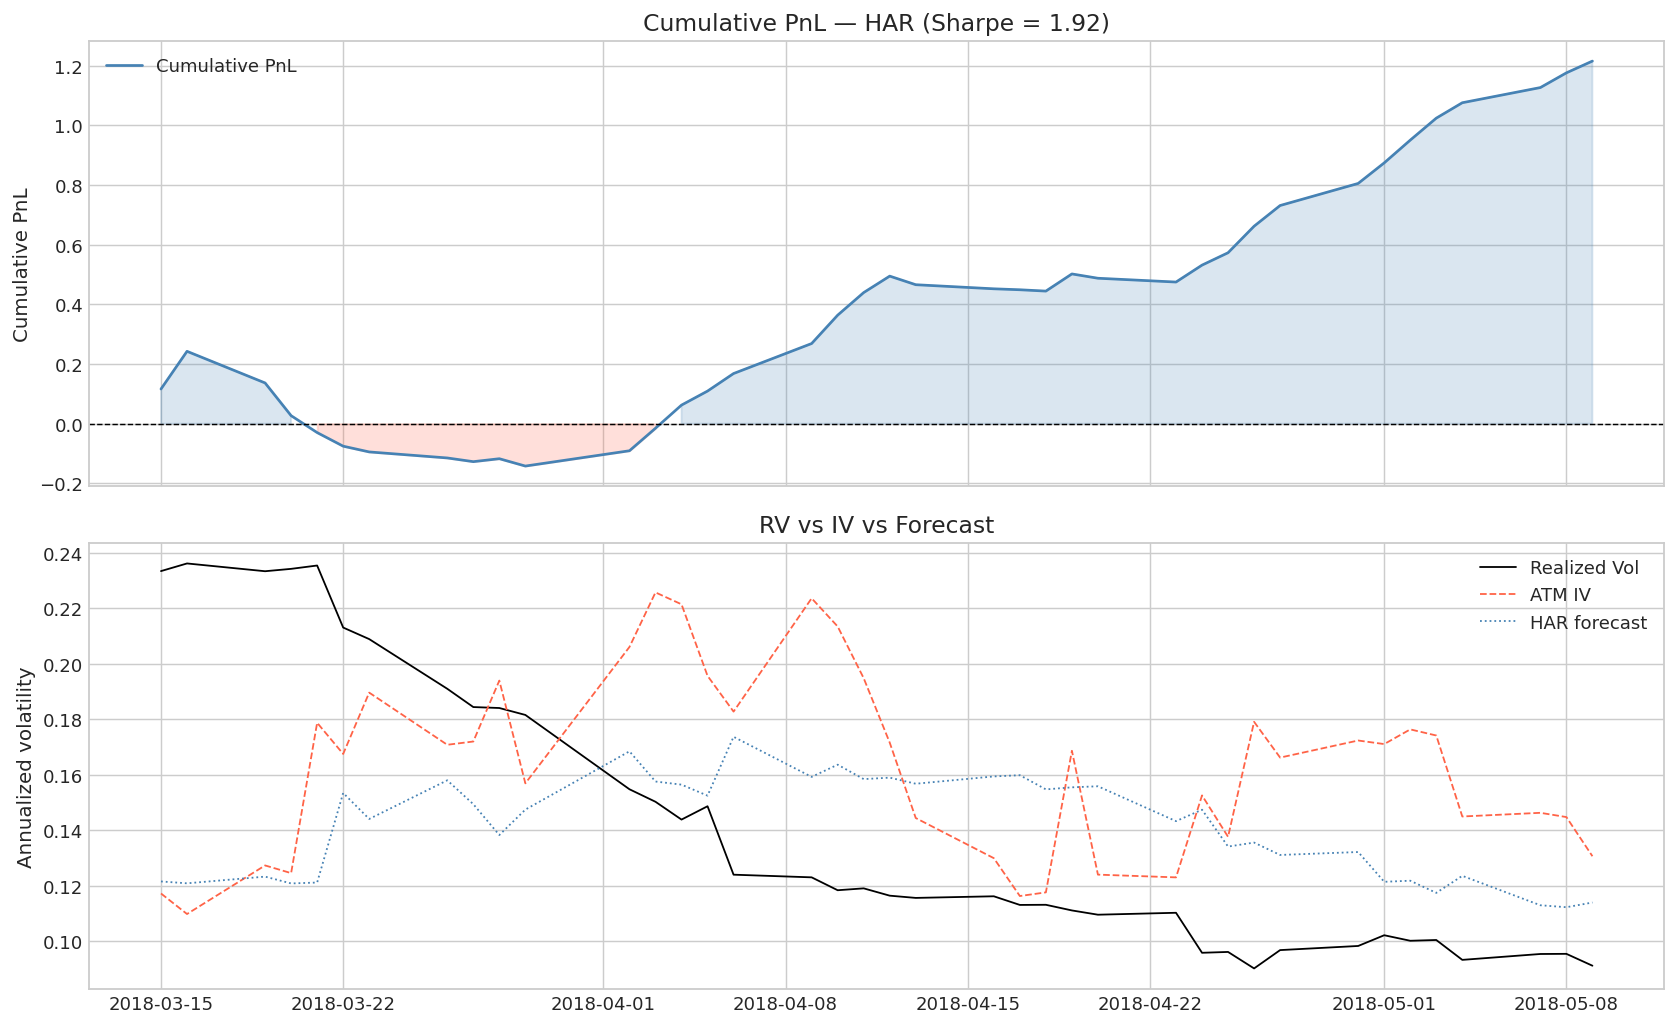

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Panel A: cumulative PnL
axes[0].plot(test_dates, cum_pnl, color='steelblue', lw=1.5, label='Cumulative PnL')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].fill_between(test_dates, cum_pnl, 0,
                      where=cum_pnl >= 0, alpha=0.2, color='steelblue')
axes[0].fill_between(test_dates, cum_pnl, 0,
                      where=cum_pnl < 0,  alpha=0.2, color='tomato')
axes[0].set_title(f'Cumulative PnL — {best_model} (Sharpe = {sharpe:.2f})')
axes[0].set_ylabel('Cumulative PnL')
axes[0].legend()

# Panel B: signal and RV vs IV
axes[1].plot(test_dates, y_test_, color='black',    lw=1,   label='Realized Vol')
axes[1].plot(test_dates, iv_test,  color='tomato',  lw=1,   ls='--', label='ATM IV')
axes[1].plot(test_dates, fc_best,  color='steelblue', lw=1, ls=':', label=f'{best_model} forecast')
axes[1].set_title('RV vs IV vs Forecast')
axes[1].set_ylabel('Annualized volatility')
axes[1].legend()

plt.tight_layout()
plt.show()